#1>Imported required libraries

In [40]:
from __future__ import print_function, division
import numpy as np
import matplotlib.pyplot as plt
from torch.utils import data
import torch
from torch import nn
from torch import optim
import torchvision
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from sklearn.model_selection import train_test_split
from tqdm import tqdm



In [41]:
import torchvision.models as models
from torch.utils.data.sampler import SubsetRandomSampler,WeightedRandomSampler
from torch.utils.data import Dataset, DataLoader
from skimage import io, transform
import torch.utils.data as data_utils
from PIL import Image, ImageFile
import json
from torch.optim import lr_scheduler
import time
import os
import argparse
import copy
import pandas as pd
ImageFile.LOAD_TRUNCATED_IMAGES = True
import cv2

import sklearn
from sklearn.metrics import cohen_kappa_score, accuracy_score,confusion_matrix

import time
from tqdm import tqdm_notebook

base_dir = "D:/"

In [42]:

import seaborn as _sns
       

In [43]:

import os, shutil, matplotlib, time
from importlib import reload



In [44]:

import time, sys, os, shutil
from importlib import reload
import matplotlib


In [45]:
train_csv = pd.read_csv("D:/train_1.csv")
test_csv = pd.read_csv("D:/test.csv")
valid_csv = pd.read_csv("D:/valid.csv")


In [46]:
print('Train Size = {}'.format(len(train_csv)))
print('Public Test Size = {}'.format(len(test_csv)))

Train Size = 2930
Public Test Size = 366


In [47]:

train_csv.head()

,id_code,diagnosis
0,1ae8c165fd53,2
1,1b329a127307,1
2,1b32e1d775ea,4
3,1b3647865779,0
4,1b398c0494d1,0


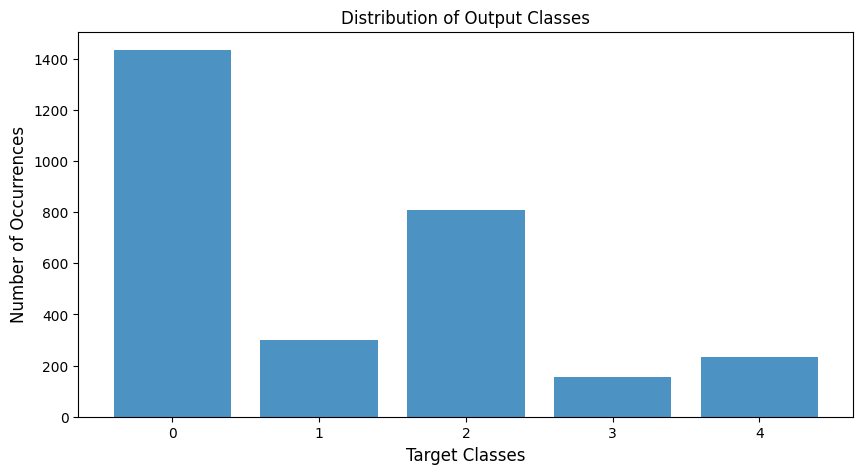

In [48]:
counts = train_csv['diagnosis'].value_counts()
class_list = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferate']
for i,x in enumerate(class_list):
    counts[x] = counts.pop(i)

plt.figure(figsize=(10,5))
plt.bar(range(len(counts.index)), counts.values, alpha=0.8)
plt.title('Distribution of Output Classes')
plt.ylabel('Number of Occurrences', fontsize=12)
plt.xlabel('Target Classes', fontsize=12)
plt.show()

#2 Visualising training and testing data

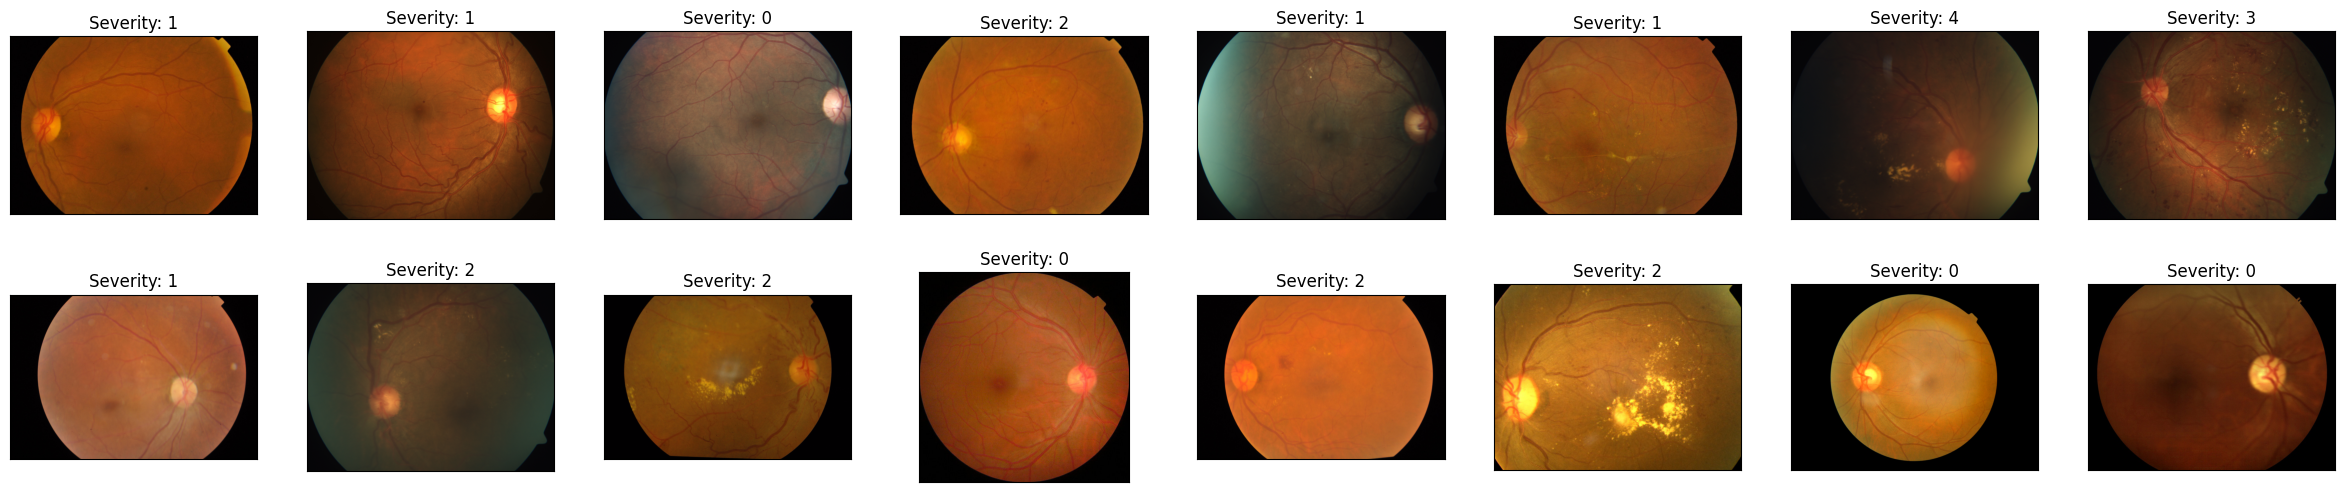

In [49]:
fig = plt.figure(figsize=(30, 6))

train_imgs = os.listdir(base_dir+"/train_images/train_images")
for idx, img in enumerate(np.random.choice(train_imgs, 16)):
    ax = fig.add_subplot(2, 16//2, idx+1, xticks=[], yticks=[])
    im = Image.open(base_dir+"/train_images/train_images/" + img)
    plt.imshow(im)
    lab = train_csv.loc[train_csv['id_code'] == img.split('.')[0], 'diagnosis'].values[0]
    ax.set_title('Severity: %s'%lab)

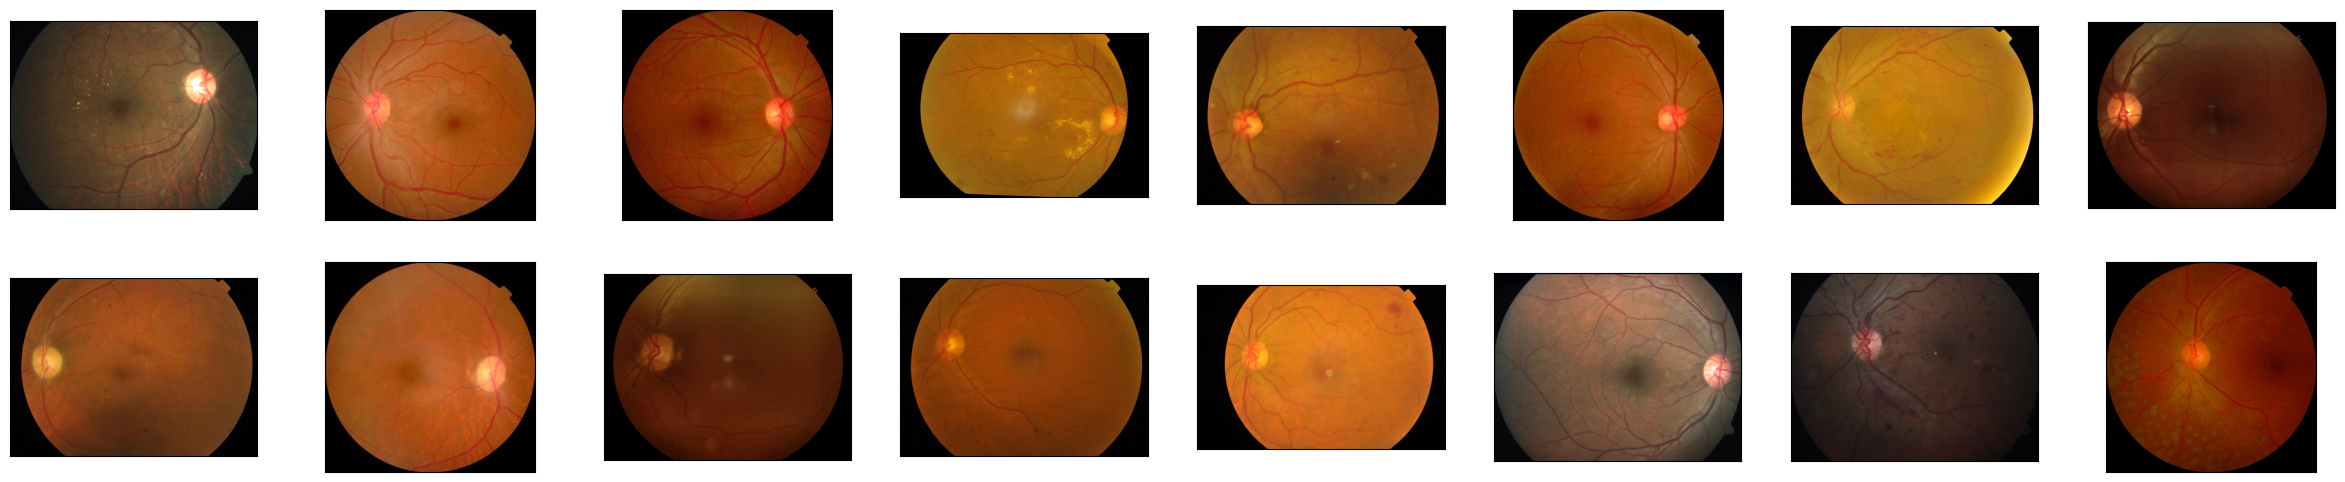

In [50]:
fig = plt.figure(figsize=(30, 6))

test_imgs = os.listdir(base_dir+"/test_images/test_images")
for idx, img in enumerate(np.random.choice(test_imgs, 16)):
    ax = fig.add_subplot(2, 16//2, idx+1, xticks=[], yticks=[])
    im = Image.open(base_dir+"/test_images/test_images/" + img)
    plt.imshow(im)

In [51]:
train_imgs,val_imgs = train_test_split(train_imgs, test_size=0.2,random_state=42)

In [52]:
# transformations
from torchvision.transforms import transforms

custom_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),  # was CenterCrop — adds spatial variation
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),  # ← add: retinal imgs have no fixed orientation
    transforms.RandomRotation(45),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2),
    transforms.RandomGrayscale(p=0.1),  # ← add: prevents colour over-reliance     transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),  # ← add: mimics focus variation
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1)),  # ← add: after ToTensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


In [53]:
val_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

In [54]:
train_path = "D:/train_images/train_images"
test_path = "D:/test_images/test_images"
valid_path = "D:/val_images/val_images"

In [55]:
"""
Preprocessing functions and custom dataset for Diabetic Retinopathy detection
Includes: black border removal, circular crop, and histogram equalization
"""

import cv2
import numpy as np
import torch
from torch.utils.data import Dataset
from PIL import Image
import pandas as pd
import os


def remove_black_borders(image, threshold=10):
    """
    Remove black borders from retinal images
    
    Args:
        image: numpy array (BGR or RGB format)
        threshold: pixel intensity threshold to consider as black (default=10)
    
    Returns:
        Cropped image with black borders removed
    """
    # Convert to grayscale for border detection
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image
    
    # Create binary mask where pixels > threshold
    _, thresh = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY)
    
    # Find contours
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if len(contours) == 0:
        return image
    
    # Get bounding box of the largest contour
    largest_contour = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest_contour)
    
    # Crop the image
    cropped = image[y:y+h, x:x+w]
    
    return cropped


def circular_crop(image, sigmaX=10):
    """
    Apply circular crop to focus on the retinal area
    
    Args:
        image: numpy array (BGR or RGB format)
        sigmaX: Gaussian blur sigma for smooth edges (default=10)
    
    Returns:
        Circularly cropped image
    """
    height, width = image.shape[:2]
    
    # Convert to grayscale for circle detection
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image
    
    # Find the center and radius of the retinal area
    # Threshold to find non-black regions
    _, thresh = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
    
    # Find contours
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if len(contours) == 0:
        return image
    
    # Get the largest contour (retinal area)
    largest_contour = max(contours, key=cv2.contourArea)
    
    # Find minimum enclosing circle
    (center_x, center_y), radius = cv2.minEnclosingCircle(largest_contour)
    center = (int(center_x), int(center_y))
    radius = int(radius)
    
    # Create circular mask
    mask = np.zeros((height, width), dtype=np.uint8)
    cv2.circle(mask, center, radius, 255, -1)
    
    # Apply Gaussian blur to create smooth edges
    mask = cv2.GaussianBlur(mask, (0, 0), sigmaX=sigmaX)
    
    # Normalize mask to 0-1 range
    mask = mask.astype(np.float32) / 255.0
    
    # Apply mask
    if len(image.shape) == 3:
        mask = np.expand_dims(mask, axis=2)
        mask = np.repeat(mask, 3, axis=2)
    
    result = (image.astype(np.float32) * mask).astype(np.uint8)
    
    return result


def apply_histogram_equalization(image, clip_limit=2.0, tile_grid_size=(8, 8)):
    """
    Apply CLAHE (Contrast Limited Adaptive Histogram Equalization)
    
    Args:
        image: numpy array (BGR or RGB format)
        clip_limit: threshold for contrast limiting (default=2.0)
        tile_grid_size: size of grid for histogram equalization (default=(8,8))
    
    Returns:
        Image with enhanced contrast
    """
    
    if len(image.shape) == 3:
        lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
        
    
        l, a, b = cv2.split(lab)
        
    
        clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
        l_equalized = clahe.apply(l)
        
        # Merge channels
        lab_equalized = cv2.merge([l_equalized, a, b])
        
        # Convert back to BGR/RGB
        result = cv2.cvtColor(lab_equalized, cv2.COLOR_LAB2BGR)
    else:
        # For grayscale images
        clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
        result = clahe.apply(image)
    
    return result


def preprocess_image(image_path, apply_border_removal=True, 
                     apply_circular=True, apply_hist_eq=True):
    """
    Complete preprocessing pipeline for retinal images
    
    Args:
        image_path: path to the image file
        apply_border_removal: whether to remove black borders (default=True)
        apply_circular: whether to apply circular crop (default=True)
        apply_hist_eq: whether to apply histogram equalization (default=True)
    
    Returns:
        Preprocessed image as PIL Image
    """
    # Read image
    image = cv2.imread(image_path)
    
    if image is None:
        raise ValueError(f"Could not read image: {image_path}")
    
    # Apply preprocessing steps
    if apply_border_removal:
        image = remove_black_borders(image, threshold=10)
    
    if apply_circular:
        image = circular_crop(image, sigmaX=10)
    
    if apply_hist_eq:
        image = apply_histogram_equalization(image, clip_limit=2.0, tile_grid_size=(8, 8))
    
    # Convert BGR to RGB
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Convert to PIL Image
    pil_image = Image.fromarray(image)
    
    return pil_image


class DRDataset(Dataset):
    """
    Custom Dataset for Diabetic Retinopathy Detection
    """
    
    def __init__(self, csv_file, root_dir, transform=None, 
                 apply_preprocessing=True, is_test=False):
        """
        Args:
            csv_file: DataFrame or path to csv file with annotations
            root_dir: Directory with all the images
            transform: Optional transform to be applied on a sample
            apply_preprocessing: Whether to apply custom preprocessing (default=True)
            is_test: Whether this is test dataset (no labels) (default=False)
        """
        if isinstance(csv_file, str):
            self.data_frame = pd.read_csv(csv_file)
        else:
            self.data_frame = csv_file
            
        self.root_dir = root_dir
        self.transform = transform
        self.apply_preprocessing = apply_preprocessing
        self.is_test = is_test
        
    def __len__(self):
        return len(self.data_frame)
    
    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()
        
        # Get image name
        img_name = os.path.join(self.root_dir, 
                               self.data_frame.iloc[idx, 0] + '.png')
        
        # Check if file exists, try .jpg if .png not found
        if not os.path.exists(img_name):
            img_name = os.path.join(self.root_dir, 
                                   self.data_frame.iloc[idx, 0] + '.jpg')
        
        # Load and preprocess image
        if self.apply_preprocessing:
            image = preprocess_image(img_name, 
                                    apply_border_removal=True,
                                    apply_circular=True, 
                                    apply_hist_eq=True)
        else:
            image = Image.open(img_name).convert('RGB')
        
        # Get label (if not test set)
        if not self.is_test:
            label = self.data_frame.iloc[idx, 1]
            label = torch.tensor(label, dtype=torch.long)
        
        # Apply transforms
        if self.transform:
            image = self.transform(image)
        
        # Return based on whether it's test set or not
        if self.is_test:
            return image, self.data_frame.iloc[idx, 0]  # Return image and image_id
        else:
            return image, label


# Example usage code
if __name__ == "__main__":
    """
    Example usage of the preprocessing functions and dataset class
    """
    
    # Test preprocessing on a single image
    print("Testing preprocessing functions...")
    
    # Example: Load and preprocess a single image
    # image_path = "path/to/your/image.png"
    # preprocessed_img = preprocess_image(image_path)
    # preprocessed_img.show()
    
    print("Preprocessing functions created successfully!")
    print("\nAvailable functions:")
    print("1. remove_black_borders(image, threshold=10)")
    print("2. circular_crop(image, sigmaX=10)")
    print("3. apply_histogram_equalization(image, clip_limit=2.0, tile_grid_size=(8,8))")
    print("4. preprocess_image(image_path, apply_border_removal=True, apply_circular=True, apply_hist_eq=True)")
    print("\nCustom Dataset class: DRDataset")

Testing preprocessing functions...
Preprocessing functions created successfully!

Available functions:
1. remove_black_borders(image, threshold=10)
2. circular_crop(image, sigmaX=10)
3. apply_histogram_equalization(image, clip_limit=2.0, tile_grid_size=(8,8))
4. preprocess_image(image_path, apply_border_removal=True, apply_circular=True, apply_hist_eq=True)

Custom Dataset class: DRDataset


In [56]:
train_data = DRDataset(train_csv, train_path, transform=custom_transform, apply_preprocessing=True,is_test=False)
test_data = DRDataset(test_csv, test_path, transform=val_transforms, apply_preprocessing=True,is_test=True)
valid_data = DRDataset(valid_csv, valid_path, transform=val_transforms, apply_preprocessing=True,is_test=False)

#3 splitting training data into validation and train data

In [57]:
from torch.utils.data import WeightedRandomSampler

class_counts = train_csv['diagnosis'].value_counts().sort_index().values
class_weights = 1. / torch.tensor(class_counts, dtype=torch.float)
sample_weights = [class_weights[label] for _, label in train_csv.values]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

In [58]:

trainloader = DataLoader(
    train_data,
    batch_size=32,
    sampler=sampler,
    num_workers=0,
    pin_memory=True,
)
validloader = DataLoader(
    valid_data,
    batch_size=32,
    num_workers=0,
    pin_memory=True,
)
testloader = DataLoader(
    test_data,
    batch_size=32,
    num_workers=0,
    pin_memory=True,
)


In [59]:
print(f"training examples contain : {len(train_data)}")
print(f"testing examples contain : {len(test_data)}")
print(f"validation examples contain : {len(valid_data)}")

print(len(trainloader))
print(len(validloader))
print(len(testloader))

training examples contain : 2930
testing examples contain : 366
validation examples contain : 366
92
12
12


In [60]:
class ChannelAttention(nn.Module):
    """
    Channel Attention Module
    """
    def __init__(self, in_channels, reduction_ratio=16):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        
        # Shared MLP
        self.fc1 = nn.Conv2d(in_channels, in_channels // reduction_ratio, 1, bias=False)
        self.relu = nn.ReLU()
        self.fc2 = nn.Conv2d(in_channels // reduction_ratio, in_channels, 1, bias=False)
        
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        # Average pooling branch
        avg_out = self.fc2(self.relu(self.fc1(self.avg_pool(x))))
        
        # Max pooling branch
        max_out = self.fc2(self.relu(self.fc1(self.max_pool(x))))
        
        # Combine and apply sigmoid
        out = self.sigmoid(avg_out + max_out)
        
        return out


class SpatialAttention(nn.Module):
    """
    Spatial Attention Module
    """
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        
        assert kernel_size in (3, 7), 'kernel size must be 3 or 7'
        padding = 3 if kernel_size == 7 else 1
        
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        # Channel-wise average and max
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        
        # Concatenate along channel dimension
        x_cat = torch.cat([avg_out, max_out], dim=1)
        
        # Apply convolution and sigmoid
        out = self.sigmoid(self.conv(x_cat))
        
        return out

In [61]:
class SpatialAttention(nn.Module):
    """
    Spatial Attention Module
    """
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        
        assert kernel_size in (3, 7), 'kernel size must be 3 or 7'
        padding = 3 if kernel_size == 7 else 1
        
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        # Channel-wise average and max
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        
        # Concatenate along channel dimension
        x_cat = torch.cat([avg_out, max_out], dim=1)
        
        # Apply convolution and sigmoid
        out = self.sigmoid(self.conv(x_cat))
        
        return out


class CBAM(nn.Module):
    """
    Convolutional Block Attention Module
    """
    def __init__(self, in_channels, reduction_ratio=16, kernel_size=7):
        super(CBAM, self).__init__()
        
        self.channel_attention = ChannelAttention(in_channels, reduction_ratio)
        self.spatial_attention = SpatialAttention(kernel_size)
    
    def forward(self, x):
        # Apply channel attention
        x = x * self.channel_attention(x)
        
        # Apply spatial attention
        x = x * self.spatial_attention(x)
        
        return x

In [62]:
class CBAM(nn.Module):
    """
    Convolutional Block Attention Module
    """
    def __init__(self, in_channels, reduction_ratio=16, kernel_size=7):
        super(CBAM, self).__init__()
        
        self.channel_attention = ChannelAttention(in_channels, reduction_ratio)
        self.spatial_attention = SpatialAttention(kernel_size)
    
    def forward(self, x):
        # Apply channel attention
        x = x * self.channel_attention(x)
        
        # Apply spatial attention
        x = x * self.spatial_attention(x)
        
        return x

In [63]:
class VGG19_CBAM(nn.Module):
    """
    VGG19 model with CBAM attention modules integrated
    """
    def __init__(self, num_classes=5, pretrained=True, freeze_features=True):
        super(VGG19_CBAM, self).__init__()

        # Load pretrained VGG19
        vgg19 = models.vgg19(pretrained=pretrained)

        # Extract feature layers
        self.features = vgg19.features

        # Freeze feature extraction layers if specified
        if freeze_features:
            for param in self.features.parameters():
                param.requires_grad = False

        # CBAM modules (same channel sizes as VGG16)
        self.cbam1 = CBAM(256, reduction_ratio=16)
        self.cbam2 = CBAM(512, reduction_ratio=16)
        self.cbam3 = CBAM(512, reduction_ratio=16)

        # Adaptive pooling
        self.avgpool = nn.AdaptiveAvgPool2d((7, 7))

        # Classifier
        self.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(True),
            nn.Dropout(0.5),
            nn.Linear(4096, 1024),
            nn.ReLU(True),
            nn.Dropout(0.5),
            nn.Linear(1024, num_classes)
        )

        self._initialize_weights()

    def forward(self, x):
        # Block 1 & 2
        for i in range(10):
            x = self.features[i](x)

        # Block 3 + CBAM
        for i in range(10, 19):   # VGG19 block3 is deeper
            x = self.features[i](x)
        x = self.cbam1(x)

        # Block 4 + CBAM
        for i in range(19, 28):
            x = self.features[i](x)
        x = self.cbam2(x)

        # Block 5 + CBAM
        for i in range(28, len(self.features)):
            x = self.features[i](x)
        x = self.cbam3(x)

        # Pooling
        x = self.avgpool(x)

        # Flatten
        x = torch.flatten(x, 1)

        # Classifier
        x = self.classifier(x)

        return x

    def _initialize_weights(self):
        for m in self.classifier.modules():
            if isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

In [64]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    """
    Train for one epoch
    """
    model.train()
    running_loss = 0.0
    running_corrects = 0
    all_preds = []
    all_labels = []
    
    # Progress bar
    pbar = tqdm(dataloader, desc='Training')
    
    for inputs, labels in pbar:
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        # Zero the parameter gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)
        
        # Backward pass and optimization
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        
        # Store predictions and labels for kappa score
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
        # Update progress bar
        pbar.set_postfix({'loss': loss.item()})
    
    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = running_corrects.double() / len(dataloader.dataset)
    epoch_kappa = cohen_kappa_score(all_labels, all_preds, weights='quadratic')
    
    return epoch_loss, epoch_acc.item(), epoch_kappa

In [65]:
def validate_epoch(model, dataloader, criterion, device):
    """
    Validate for one epoch
    """
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    all_preds = []
    all_labels = []
    
    # Progress bar
    pbar = tqdm(dataloader, desc='Validation')
    
    with torch.no_grad():
        for inputs, labels in pbar:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            # Forward pass
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)
            
            # Statistics
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            
            # Store predictions and labels
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
            # Update progress bar
            pbar.set_postfix({'loss': loss.item()})
    
    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = running_corrects.double() / len(dataloader.dataset)
    epoch_kappa = cohen_kappa_score(all_labels, all_preds, weights='quadratic')
    
    return epoch_loss, epoch_acc.item(), epoch_kappa, all_preds, all_labels


In [66]:
def save_checkpoint(epoch, model, optimizer, scheduler, history, best_kappa, 
                   checkpoint_path='checkpoint_epoch.pth'):
    """
    Save a training checkpoint that can be resumed later
    
    Args:
        epoch: Current epoch number
        model: The model being trained
        optimizer: The optimizer
        scheduler: The learning rate scheduler
        history: Training history dictionary
        best_kappa: Best kappa score so far
        checkpoint_path: Path to save the checkpoint
    """
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'history': history,
        'best_kappa': best_kappa,
    }
    torch.save(checkpoint, checkpoint_path)
    print(f'✓ Checkpoint saved to {checkpoint_path} at epoch {epoch+1}')


In [67]:
def load_checkpoint(checkpoint_path, model, optimizer=None, scheduler=None, device='cpu'):
    """
    Load a training checkpoint to resume training
    
    Args:
        checkpoint_path: Path to the checkpoint file
        model: The model to load weights into
        optimizer: The optimizer to load state into (optional)
        scheduler: The scheduler to load state into (optional)
        device: Device to load the model on
    
    Returns:
        start_epoch: Epoch to resume from
        history: Training history
        best_kappa: Best kappa score
    """
    print(f'Loading checkpoint from {checkpoint_path}...')
    checkpoint = torch.load(checkpoint_path, map_location=device)
    
    # Load model state
    model.load_state_dict(checkpoint['model_state_dict'])
    
    # Load optimizer state if provided
    if optimizer is not None and 'optimizer_state_dict' in checkpoint:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    
    # Load scheduler state if provided
    if scheduler is not None and 'scheduler_state_dict' in checkpoint:
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    
    # Get training info
    start_epoch = checkpoint['epoch'] + 1  # Resume from next epoch
    history = checkpoint.get('history', {
        'train_loss': [], 'train_acc': [], 'train_kappa': [],
        'val_loss': [], 'val_acc': [], 'val_kappa': []
    })
    best_kappa = checkpoint.get('best_kappa', 0.0)
    
    print(f'✓ Checkpoint loaded!')
    print(f'  Resuming from epoch {start_epoch}')
    print(f'  Best kappa so far: {best_kappa:.4f}')
    print(f'  Training history has {len(history["train_loss"])} epochs')
    
    return start_epoch, history, best_kappa

In [68]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, 
                num_epochs, device, save_path='best_model.pth', 
                checkpoint_path='checkpoint_latest.pth', 
                save_checkpoint_every=10,
                resume_from_checkpoint=None):
    """
    Complete training loop with validation
    """
    since = time.time()
    
    best_model_wts = copy.deepcopy(model.state_dict())
    best_kappa = 0.0
    patience = 15
    patience_counter = 0
    start_epoch  =0
    epoch = 0

    # History
    history = {
        'train_loss': [],
        'train_acc': [],
        'train_kappa': [],
        'val_loss': [],
        'val_acc': [],
        'val_kappa': []
    }

    if os.path.exists(checkpoint_path):     
        start_epoch, history, best_kappa = load_checkpoint(         
            checkpoint_path, model, optimizer, scheduler, device     
        )     
        best_model_wts = copy.deepcopy(model.state_dict())

    if resume_from_checkpoint is not None:
        start_epoch, history, best_kappa = load_checkpoint(
            resume_from_checkpoint, model, optimizer, scheduler, device
        )
        best_model_wts = copy.deepcopy(model.state_dict())
        print(f'\n>>> Resuming training from epoch {start_epoch + 1}\n')
    
    for epoch in range(start_epoch,num_epochs):
        print(f'\nEpoch {epoch+1}/{num_epochs}')
        print('-' * 60)
        
        # Training phase
        train_loss, train_acc, train_kappa = train_epoch(
            model, train_loader, criterion, optimizer, device
        )
        
        # Validation phase
        val_loss, val_acc, val_kappa, val_preds, val_labels = validate_epoch(
            model, val_loader, criterion, device
        )
        
        # Learning rate scheduler step
        scheduler.step(val_loss)
        
        # Print statistics
        print(f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train Kappa: {train_kappa:.4f}')
        print(f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val Kappa: {val_kappa:.4f}')
        print(f'Learning Rate: {optimizer.param_groups[0]["lr"]:.6f}')
        
        # Save history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['train_kappa'].append(train_kappa)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_kappa'].append(val_kappa)
        
        # Deep copy the model if it's the best so far
        if val_kappa > best_kappa:
            best_kappa = val_kappa
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'best_kappa': best_kappa,
                'history': history
            }, save_path)
            print(f'>>> Model saved! Best Kappa: {best_kappa:.4f}')
            patience_counter = 0
        else:
            patience_counter += 1  # ← add     
            print(f"No improvement. Patience {patience_counter}/{patience}")     
            if patience_counter >= patience:         
                print(f"Early stopping triggered at epoch {epoch+1}. Best kappa: {best_kappa:.4f}")         
                break    

        save_checkpoint(         
            epoch, model, optimizer, scheduler, history, best_kappa,
            checkpoint_path=checkpoint_path  # ← always the same file     
            )   
    
    time_elapsed = time.time() - since
    print(f'\nTraining complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best Validation Kappa: {best_kappa:.4f}')

    # ────────────────────────────────────────────────────────────────
    # Added: Save final history (very useful for resuming analysis)
    # ────────────────────────────────────────────────────────────────
    final_history_path = checkpoint_path.replace('.pth', '_history_final.pth')
    torch.save(history, final_history_path)
    print(f'>>> Final training history saved to: {final_history_path}')

    # Save final checkpoint
    save_checkpoint(
        epoch, model, optimizer, scheduler, history, best_kappa,
        checkpoint_path=checkpoint_path.replace('.pth', '_final.pth')
    )
    
    # Load best model weights
    model.load_state_dict(best_model_wts)
    
    return model, history

In [69]:
def plot_training_history(history, save_path='training_history.png'):
    """
    Plot training history
    """
    import matplotlib.pyplot as plt
    
    epochs = range(1, len(history['train_loss']) + 1)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Loss
    axes[0].plot(epochs, history['train_loss'], 'b-', label='Train Loss')
    axes[0].plot(epochs, history['val_loss'], 'r-', label='Val Loss')
    axes[0].set_title('Training and Validation Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)
    
    # Accuracy
    axes[1].plot(epochs, history['train_acc'], 'b-', label='Train Acc')
    axes[1].plot(epochs, history['val_acc'], 'r-', label='Val Acc')
    axes[1].set_title('Training and Validation Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True)
    
    # Kappa Score
    axes[2].plot(epochs, history['train_kappa'], 'b-', label='Train Kappa')
    axes[2].plot(epochs, history['val_kappa'], 'r-', label='Val Kappa')
    axes[2].set_title('Training and Validation Kappa Score')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Kappa Score')
    axes[2].legend()
    axes[2].grid(True)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def evaluate_model(model, dataloader, device):
    """
    Evaluate model and print detailed metrics
    """
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc='Evaluating'):
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # Calculate metrics
    accuracy = accuracy_score(all_labels, all_preds)
    kappa = cohen_kappa_score(all_labels, all_preds, weights='quadratic')
    cm = confusion_matrix(all_labels, all_preds)
    
    print(f'\nEvaluation Results:')
    print(f'Accuracy: {accuracy:.4f}')
    print(f'Quadratic Kappa Score: {kappa:.4f}')
    print(f'\nConfusion Matrix:')
    print(cm)
    
    return accuracy, kappa, cm

if __name__ == "__main__":
    print("VGG16-CBAM Model for Diabetic Retinopathy Detection")
    print("=" * 60)
    
    # Check device
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    
    # Create model
    model = VGG19_CBAM(num_classes=5, pretrained=True, freeze_features=True)
    print("\nModel created successfully!")
    
    # Print model summary
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nTotal parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")

VGG16-CBAM Model for Diabetic Retinopathy Detection
Using device: cuda:0


c:\Users\ajays\diabetic-retinopathy-detection-main\project-env\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\ajays\diabetic-retinopathy-detection-main\project-env\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



Model created successfully!

Total parameters: 127,063,403
Trainable parameters: 107,039,019


In [70]:
model = VGG19_CBAM(
    num_classes=5,           # 5 DR stages (0-4)
    pretrained=True,         # Use pretrained VGG19 weights
    freeze_features=True     # Freeze convolutional layers
)


In [71]:
model = model.to(device)

In [72]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.001,
    weight_decay=1e-4 
)

In [73]:
scheduler = lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=10,
    min_lr=1e-4
)

In [77]:
import os

if os.path.exists('checkpoint.pt'):
    os.remove('checkpoint.pt')
    print("Corrupted checkpoint removed")
else:
    print("No checkpoint found")

No checkpoint found


In [76]:
save_path = 'best_vgg16_cbam_dr_130epochs.pth'
trained_model, history = train_model(
    model=model,
    train_loader=trainloader,
    val_loader=validloader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=141,
    device=device,
    save_path=save_path,
    checkpoint_path='checkpoint.pt',
)


Epoch 1/141
------------------------------------------------------------


Training:   0%|          | 0/92 [00:04<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
def plot_training_history(history):
    """Plot training and validation metrics"""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Loss
    axes[0].plot(history['train_loss'], label='Train Loss')
    axes[0].plot(history['val_loss'], label='Val Loss')
    axes[0].set_title('Loss over Epochs')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)
    
    # Accuracy
    axes[1].plot(history['train_acc'], label='Train Acc')
    axes[1].plot(history['val_acc'], label='Val Acc')
    axes[1].set_title('Accuracy over Epochs')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True)
    
    # Kappa
    axes[2].plot(history['train_kappa'], label='Train Kappa')
    axes[2].plot(history['val_kappa'], label='Val Kappa')
    axes[2].set_title('Quadratic Kappa over Epochs')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Kappa')
    axes[2].legend()
    axes[2].grid(True)
    
    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150)
    print("Training history saved as 'training_history.png'")

In [ ]:
plot_training_history(history)

NameError: name 'history' is not defined

In [ ]:
from visual_shap_explainer import explain_test_images_visual
import torch

# After running XGBoost (you have X_train, test_ids, y_test)

test_img_dir = 'D:/test_images/test_images'

explain_test_images_visual(
    test_image_dir=test_img_dir,
    test_ids=test_ids[:2],  # First two test images
    xgb_model_path='xgboost_dr_model.json',
    vgg_weights_path='best_vgg16_cbam_dr_130epochs.pth',
    X_background=X_train,  # Use training features for SHAP baseline
    device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    true_labels=y_test[:2] if 'y_test' in globals() else None,  # Optional
    num_images=2
)




c:\Users\ajays\diabetic-retinopathy-detection-main\project-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


NameError: name 'test_ids' is not defined

In [ ]:
import torch
from torch.cuda.amp import autocast, GradScaler
def train_and_validate_amp(
    model,
    epochs=80,
    start_epoch = 0,                      
    patience=10,
    trainloader=None,
    validloader=None,
    criterion=None,
    optimizer=None,
    scheduler=None,
    device=None,
    save_path="best_model_cbam.pt",
    phys_batch_size=16,
    virtual_batch_size=32,
    acc_threshold=0.90
):
    accum_steps = virtual_batch_size // phys_batch_size
    scaler = GradScaler()

    train_losses, val_losses, val_accs = [], [], []

    best_val_loss = float("inf")
    best_val_acc = 0.0
    patience_counter = 0
    monitoring_started = False  

    
    conv5_unfrozen = False
    conv4_unfrozen = False

    checkpoint_path = "checkpoint.pth"

    start_epoch = 0

    if os.path.exists(checkpoint_path):
     print("Loading checkpoint...")
     checkpoint = torch.load(checkpoint_path, map_location=device)

     model.load_state_dict(checkpoint['model_state_dict'])
     optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
     start_epoch = checkpoint['epoch'] + 1

     print(f"Resuming training from epoch {start_epoch}")
    else:
     print("No checkpoint found. Starting fresh training.")
    for epoch in range(start_epoch,epochs):
        
        if (epoch + 1) == 16 and not conv5_unfrozen:
            for param in model.features[24:].parameters():  
                param.requires_grad = True
            for g in optimizer.param_groups:
                g["lr"] = 1e-5
            conv5_unfrozen = True
            print(f"Epoch {epoch+1}: conv5 unfrozen, LR lowered to 1e-5")

        
        if (epoch + 1) == 41 and not conv4_unfrozen:
            for param in model.features[17:24].parameters():  
                param.requires_grad = True
            for g in optimizer.param_groups:
                g["lr"] = 1e-6
            conv4_unfrozen = True
            print(f"Epoch {epoch+1}: conv4 unfrozen, LR lowered to 1e-6")

        
        
        
        model.train()
        running_loss = 0.0
        optimizer.zero_grad()

        for batch_idx, (images, labels) in enumerate(trainloader):
            images, labels = images.to(device), labels.to(device)

            with autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss = loss / accum_steps  

            scaler.scale(loss).backward()
            running_loss += loss.item() * accum_steps

            if (batch_idx + 1) % accum_steps == 0:
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()

        
        model.eval()
        val_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in validloader:
                images, labels = images.to(device), labels.to(device)
                with autocast():
                    outputs = model(images)
                    loss = criterion(outputs, labels)
                    val_loss += loss.item()
                    _, preds = torch.max(outputs, 1)
                    correct += (preds == labels).sum().item()
                    total += labels.size(0)

        epoch_train_loss = running_loss / len(trainloader)
        epoch_val_loss = val_loss / len(validloader)
        epoch_val_acc = correct / total

        train_losses.append(epoch_train_loss)
        val_losses.append(epoch_val_loss)
        val_accs.append(epoch_val_acc)

        
        if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step(epoch_val_loss)
        else:
            scheduler.step()

        print(
            f"Epoch {epoch+1}/{epochs}.. "
            f"Train Loss: {epoch_train_loss:.4f}.. "
            f"Val Loss: {epoch_val_loss:.4f}.. "
            f"Val Acc: {epoch_val_acc:.4f}"
        )

        save_checkpoint(
            "checkpoint.pt", 
             model, optimizer, scheduler, 
             epoch, best_val_acc, best_val_loss
        )
        
        if not monitoring_started:
            if epoch_val_acc >= acc_threshold:
                monitoring_started = True
                best_val_acc = epoch_val_acc
                best_val_loss = epoch_val_loss
                patience_counter = 0
                torch.save(model.state_dict(), save_path)
                print(f"Validation acc crossed {acc_threshold*100:.1f}%, monitoring activated!")
        else:
            if epoch_val_acc >= best_val_acc:
                best_val_acc = epoch_val_acc
                best_val_loss = epoch_val_loss
                patience_counter = 0
                torch.save(model.state_dict(), save_path)
                print("Validation accuracy improved, model saved.")
            else:
                patience_counter += 1
                print(f"No improvement. Patience counter {patience_counter}/{patience}")
                if patience_counter >= patience:
                    print("Early stopping triggered due to deterioration after reaching threshold.")
                    break

    print("Training completed successfully!")
    return train_losses, val_losses, val_accs



